In [1]:
import sys
import os

# Add the root project directory to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

In [2]:
from src.data_loader import load_data
from src.data_cleaner import check_missing_values, convert_types, drop_useless_columns, fill_missing_values
from src.data_analyzer import describe_numerical, compute_loss_ratio
from src.data_visualizer import plot_hist_and_box, plot_claims_over_time, plot_top_and_bottom_models_by_claims

In [3]:
df = load_data("../data/MachineLearningRating_v3/MachineLearningRating_v3.txt")

✅ Loaded data with shape: (1000098, 52)


In [9]:
df.head(2)

,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0


In [4]:
# datetime conversion
df = convert_types(df)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 52 columns):
 #   Column                    Non-Null Count    Dtype         
---  ------                    --------------    -----         
 0   UnderwrittenCoverID       1000098 non-null  int64         
 1   PolicyID                  1000098 non-null  int64         
 2   TransactionMonth          1000098 non-null  datetime64[ns]
 3   IsVATRegistered           1000098 non-null  bool          
 4   Citizenship               1000098 non-null  object        
 5   LegalType                 1000098 non-null  object        
 6   Title                     1000098 non-null  object        
 7   Language                  1000098 non-null  object        
 8   Bank                      854137 non-null   object        
 9   AccountType               959866 non-null   object        
 10  MaritalStatus             991839 non-null   object        
 11  Gender                    990562 non-null   object

In [5]:
# check missing values
print(check_missing_values(df))

NumberOfVehiclesInFleet    1000098
CrossBorder                 999400
CustomValueEstimate         779642
Converted                   641901
Rebuilt                     641901
WrittenOff                  641901
NewVehicle                  153295
Bank                        145961
AccountType                  40232
Gender                        9536
MaritalStatus                 8259
Cylinders                      552
cubiccapacity                  552
kilowatts                      552
NumberOfDoors                  552
VehicleIntroDate               552
Model                          552
make                           552
VehicleType                    552
mmcode                         552
bodytype                       552
CapitalOutstanding               2
dtype: int64


In [5]:
#  drop useless columns
df = drop_useless_columns(df, ['NumberOfVehiclesInFleet', 'CrossBorder'])

In [6]:
# fill missing values and drop rows with missing target values
df = fill_missing_values(df)

📥 Original shape: (1000098, 50)
✅ Cleaned shape: (999544, 50)
🧹 Rows removed during cleaning: 554


In [7]:
# check missing values again
print(check_missing_values(df))

Series([], dtype: int64)


In [ ]:
# Descriptive statistics
print(describe_numerical(df))

       UnderwrittenCoverID       PolicyID               TransactionMonth  \
count        999544.000000  999544.000000                         999544   
mean         104805.651873    7956.004267  2015-02-28 10:32:53.181370368   
min               1.000000      14.000000            2013-10-01 00:00:00   
25%           55128.000000    4500.000000            2015-01-01 00:00:00   
50%           94073.000000    7071.000000            2015-04-01 00:00:00   
75%          139190.000000   11077.000000            2015-06-01 00:00:00   
max          301175.000000   23246.000000            2015-08-01 00:00:00   
std           63297.157788    5290.000123                            NaN   

          PostalCode        mmcode  RegistrationYear      Cylinders  \
count  999544.000000  9.995440e+05     999544.000000  999544.000000   
mean     3019.836643  5.487769e+07       2010.224983       4.046642   
min         1.000000  4.041200e+06       1987.000000       0.000000   
25%       821.000000  6.005692e

In [8]:
# Loss ratio computation
loss_ratios = compute_loss_ratio(df)

In [9]:
# print loss ratios
loss_ratios.head()

,Province,VehicleType,Gender,LossRatio
45,Northern Cape,Heavy Commercial,Not specified,2.172783
2,Eastern Cape,Medium Commercial,Not specified,1.684985
9,Gauteng,Light Commercial,Not specified,1.569932
51,Western Cape,Heavy Commercial,Not specified,1.459208
31,Mpumalanga,Heavy Commercial,Not specified,1.235708


In [ ]:
# plot_hist(df, "TotalPremium")
# plot_box(df, "CustomValueEstimate")
# plot_correlation(df)

### What are the distributions of key financial variables?

Are there outliers in TotalClaims or CustomValueEstimate?

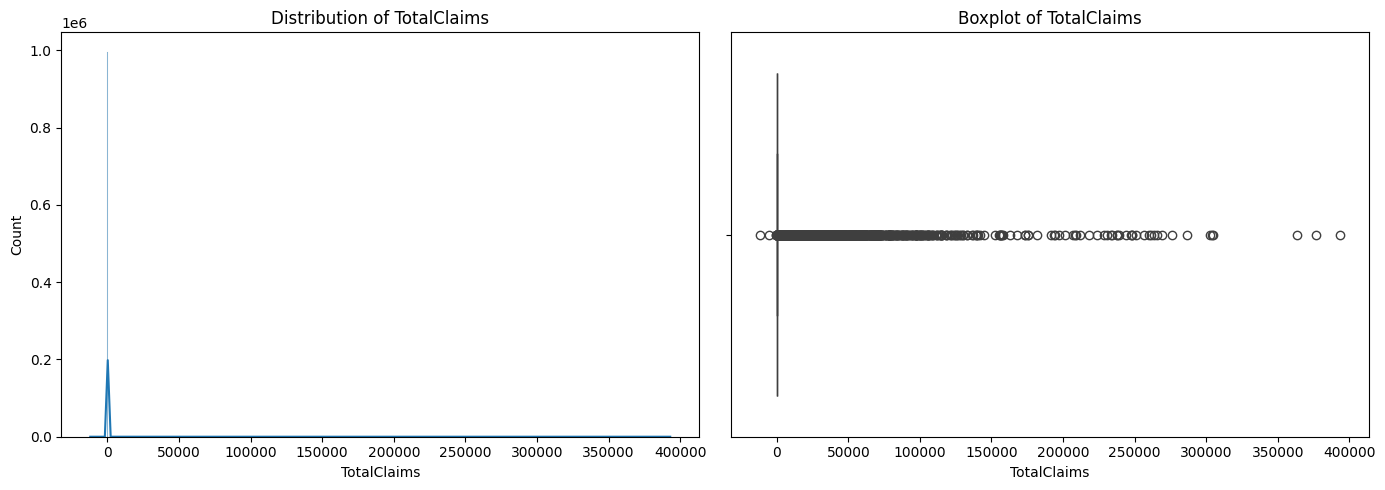

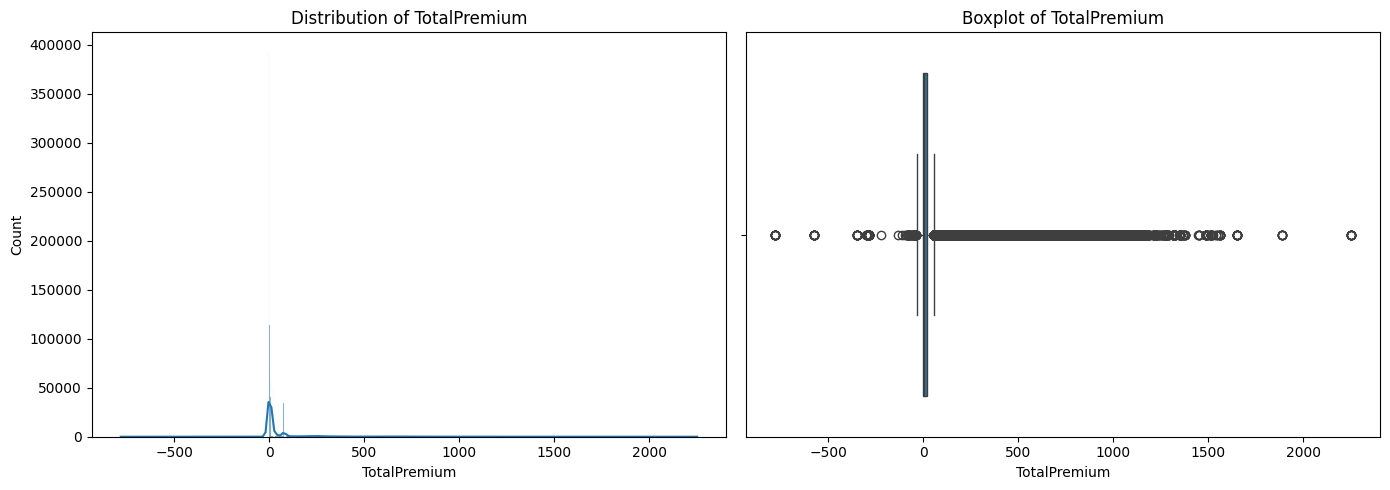

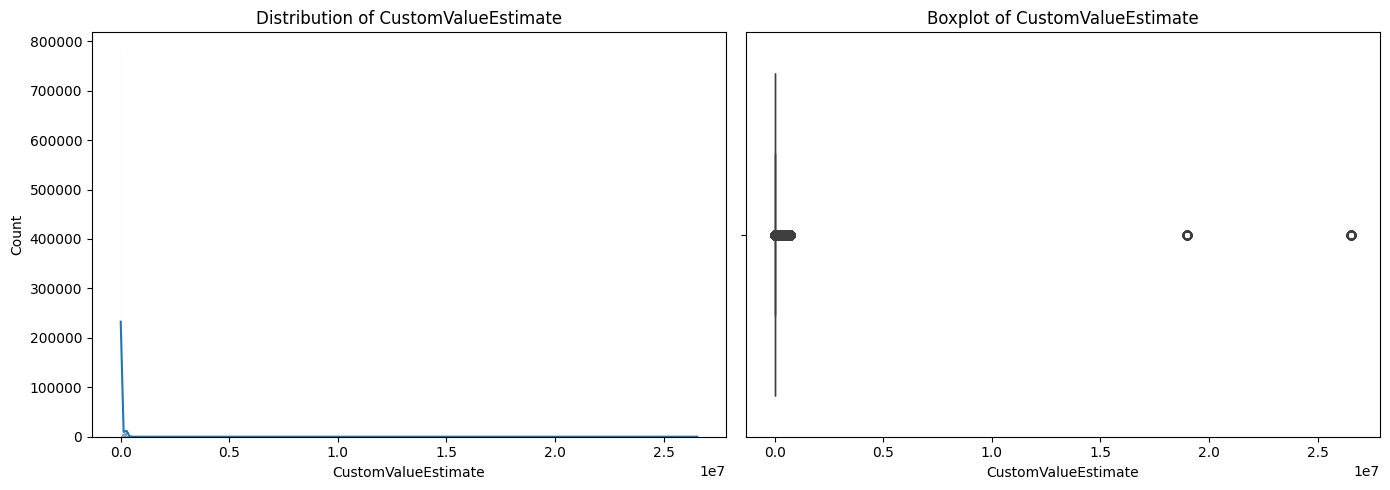

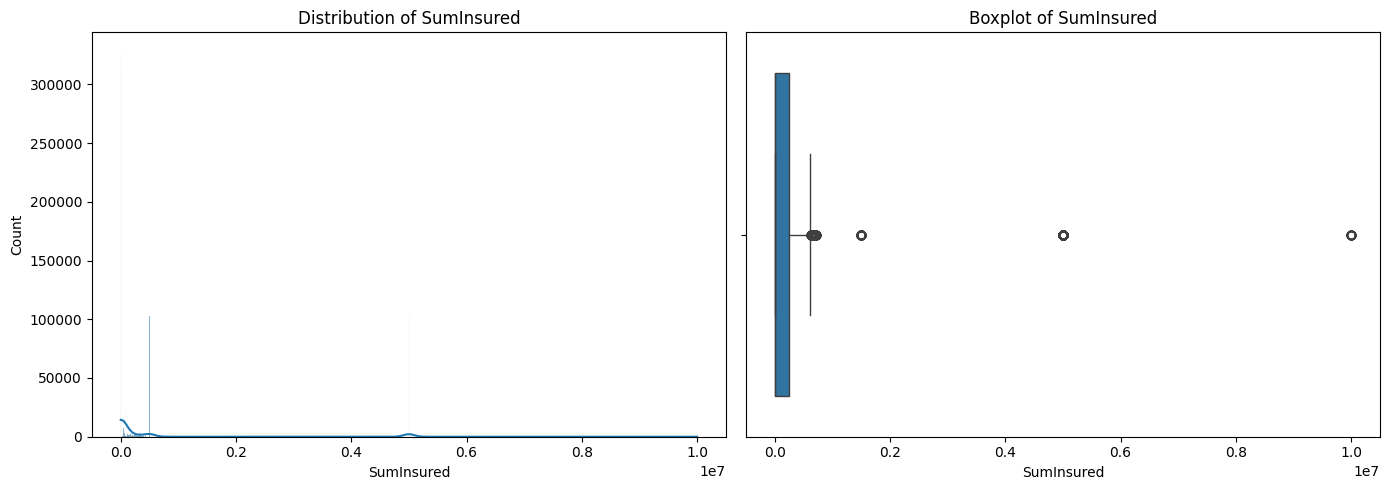

In [8]:
for col in ['TotalClaims', 'TotalPremium', 'CustomValueEstimate', 'SumInsured']:
    plot_hist_and_box(df, col)

### Are there temporal trends?

Plot claim trends over time

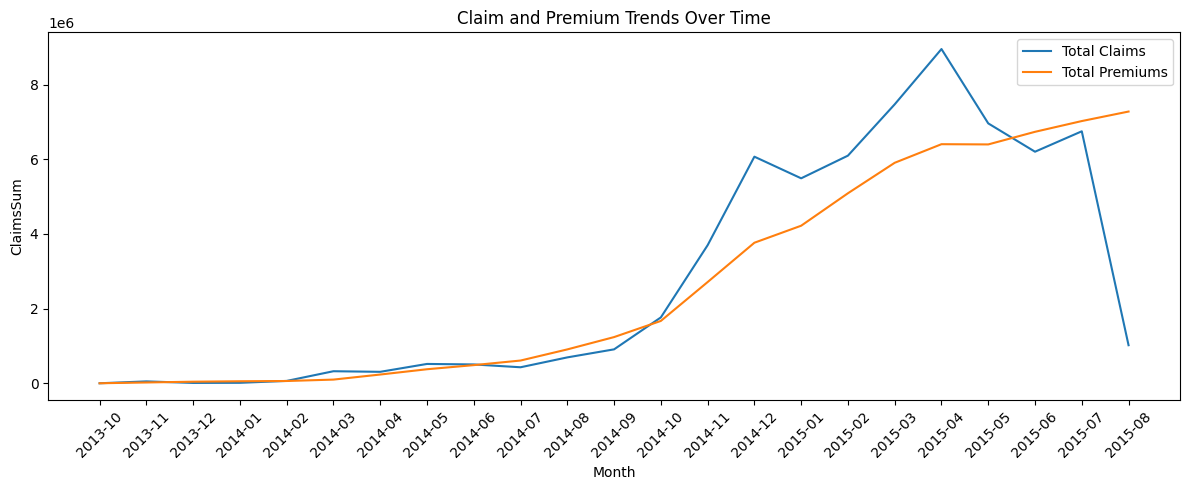

In [9]:
plot_claims_over_time(df)

### Which vehicle make/models have highest and lowest claim amounts?

Top Claiming Models:


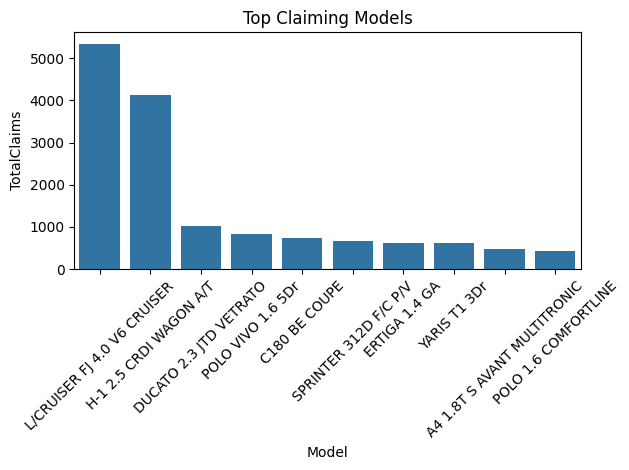

 Top Claiming Models:
                                  make                        Model  \
0                               TOYOTA  L/CRUISER FJ 4.0 V6 CRUISER   
1                              HYUNDAI       H-1 2.5 CRDI WAGON A/T   
2                                 FIAT       DUCATO 2.3 JTD VETRATO   
3                           VOLKSWAGEN            POLO VIVO 1.6 5Dr   
4                        MERCEDES-BENZ                C180 BE COUPE   
5                        MERCEDES-BENZ        SPRINTER 312D F/C P/V   
6  SUZUKI                                             ERTIGA 1.4 GA   
7                               TOYOTA                 YARIS T1 3Dr   
8                                 AUDI  A4 1.8T S AVANT MULTITRONIC   
9                           VOLKSWAGEN         POLO 1.6 COMFORTLINE   

   TotalClaims  
0  5340.970273  
1  4118.181043  
2  1014.681021  
3   827.558882  
4   743.459027  
5   664.540138  
6   631.774519  
7   618.719846  
8   480.282859  
9   431.842105  

Lowest C

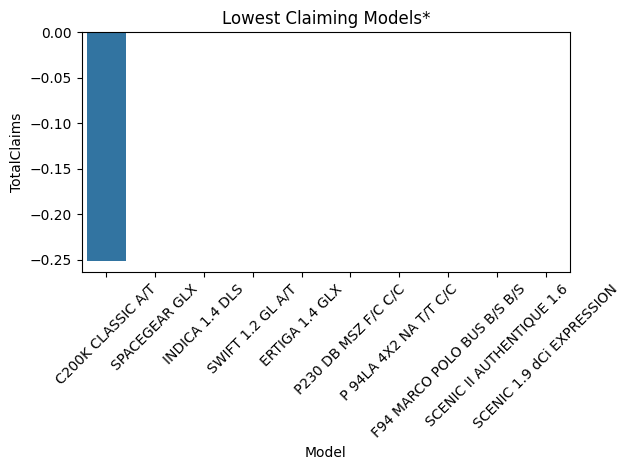


 Lowest Claiming Models:
                                  make                       Model  \
0                        MERCEDES-BENZ           C200K CLASSIC A/T   
1                           MITSUBISHI               SPACEGEAR GLX   
2                                 TATA              INDICA 1.4 DLS   
3  SUZUKI                                         SWIFT 1.2 GL A/T   
4  SUZUKI                                           ERTIGA 1.4 GLX   
5                               SCANIA         P230 DB MSZ F/C C/C   
6                               SCANIA       P 94LA 4X2 NA T/T C/C   
7                               SCANIA  F94 MARCO POLO BUS B/S B/S   
8                              RENAULT   SCENIC II AUTHENTIQUE 1.6   
9                              RENAULT   SCENIC 1.9 dCi EXPRESSION   

   TotalClaims  
0    -0.250832  
1     0.000000  
2     0.000000  
3     0.000000  
4     0.000000  
5     0.000000  
6     0.000000  
7     0.000000  
8     0.000000  
9     0.000000  


In [10]:
plot_top_and_bottom_models_by_claims(df)